## Intro

In [1]:
print('Hello_World')

Hello_World


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('heart_disease_uci.csv')

In [4]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Understanding Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [6]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [7]:
df['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [8]:
df['dataset'].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

In [9]:
df['cp'].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

In [10]:
df['fbs'].value_counts()

fbs
False    692
True     138
Name: count, dtype: int64

In [11]:
df['restecg'].value_counts()

restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64

In [12]:
df['exang'].value_counts()

exang
False    528
True     337
Name: count, dtype: int64

In [13]:
df['slope'].value_counts()

slope
flat           345
upsloping      203
downsloping     63
Name: count, dtype: int64

In [14]:
df['thal'].value_counts()

thal
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64

In [15]:
df['num'].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [16]:
df.shape

(920, 16)

In [17]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

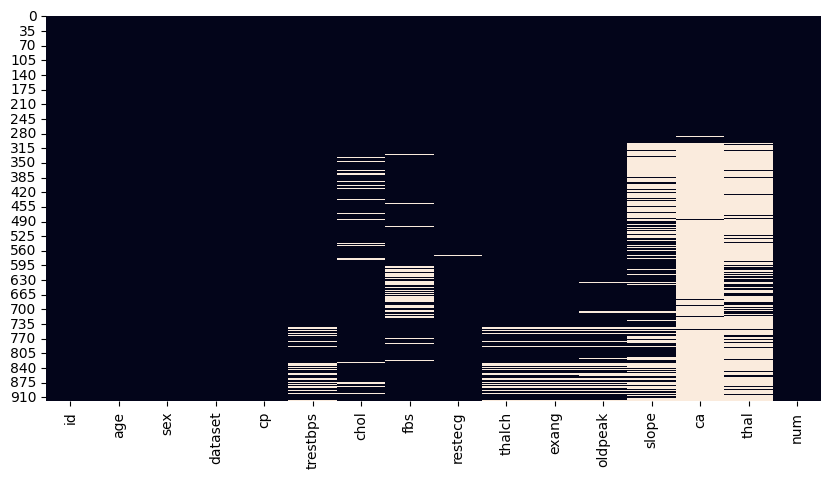

In [18]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [19]:
df.duplicated().sum()

np.int64(0)

## EDA

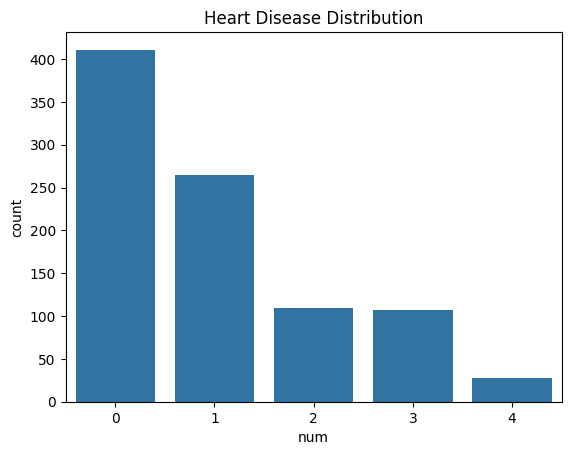

In [20]:
sns.countplot(x='num', data=df)
plt.title('Heart Disease Distribution')
plt.show()

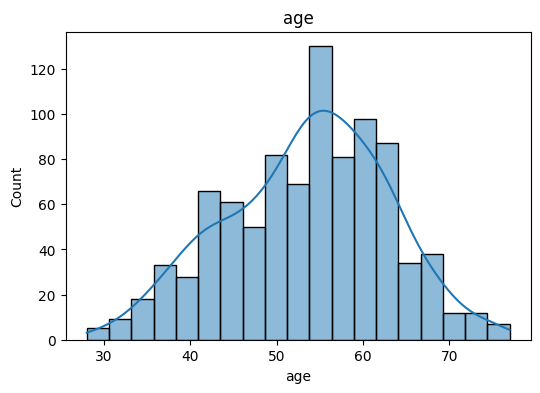

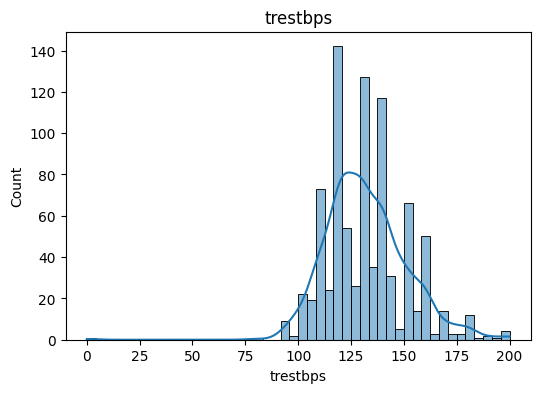

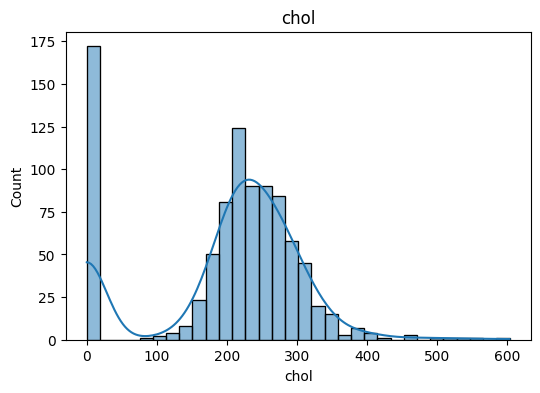

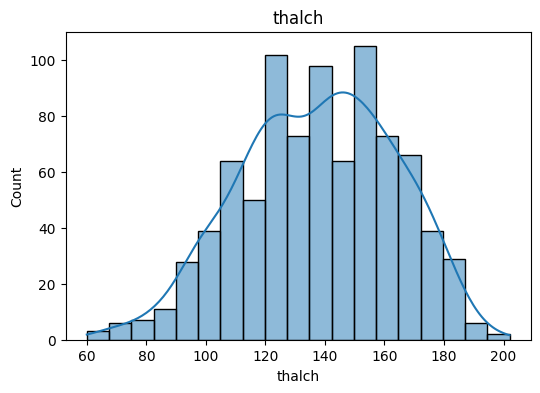

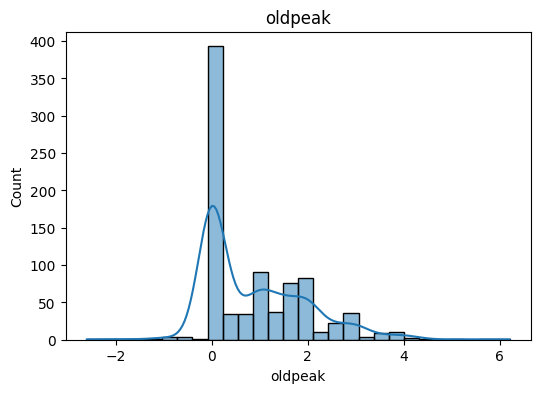

In [21]:
num_cols = ['age','trestbps','chol','thalch','oldpeak']
for col in num_cols:                                                                #for normality,skewness,multimodel distributions of num columns
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

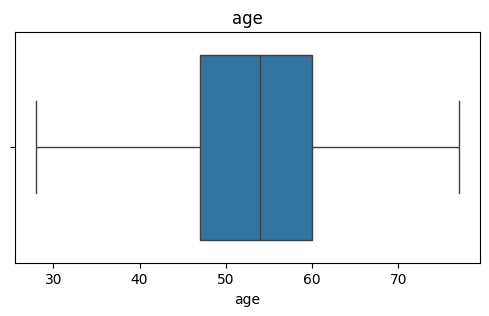

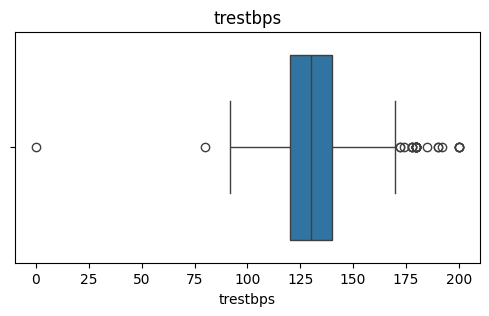

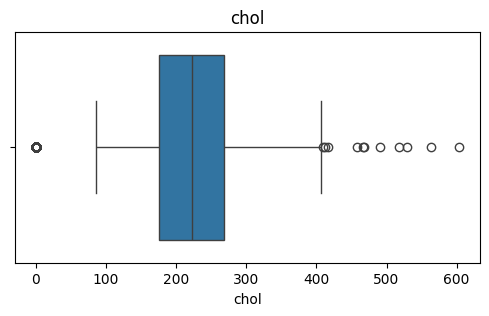

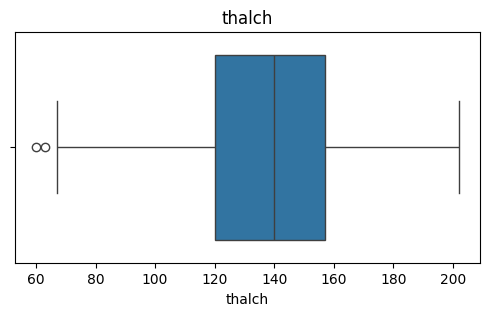

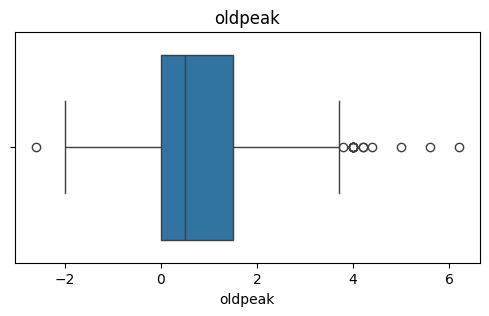

In [22]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

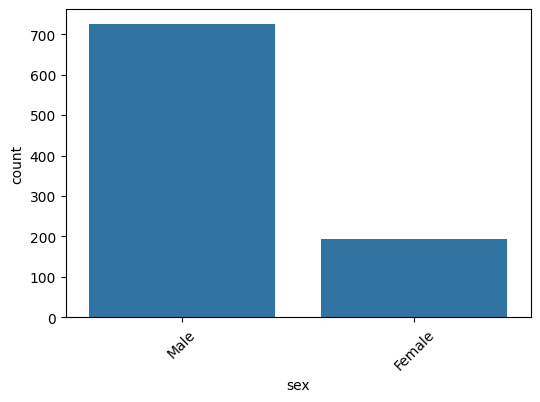

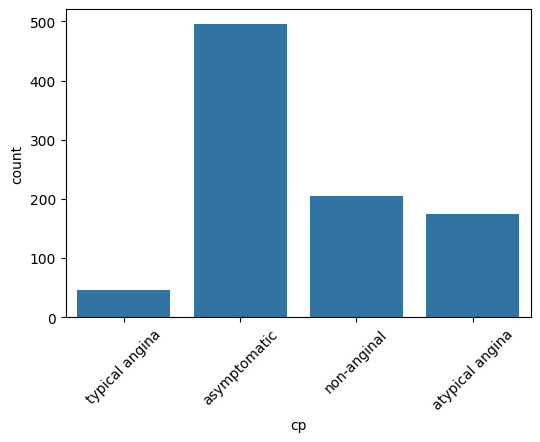

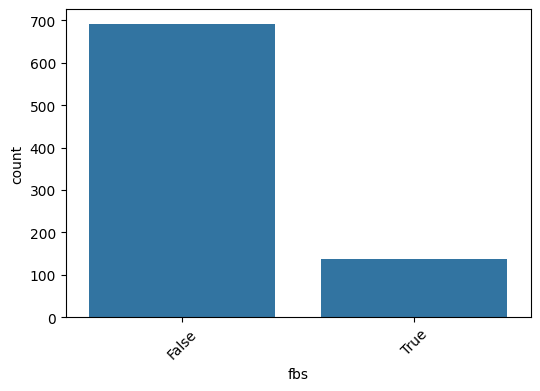

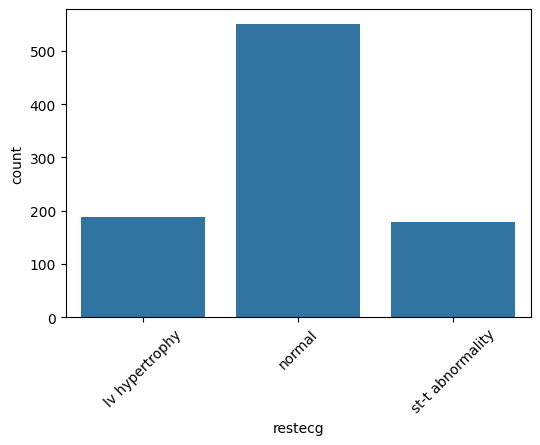

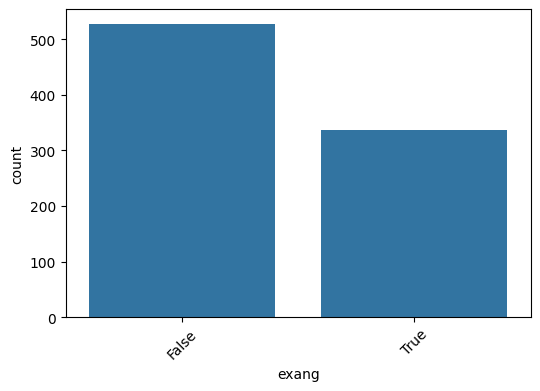

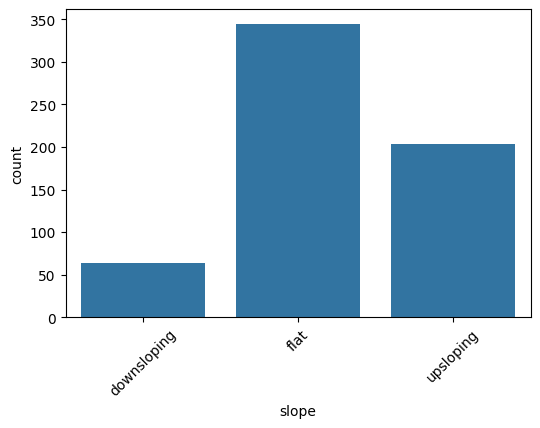

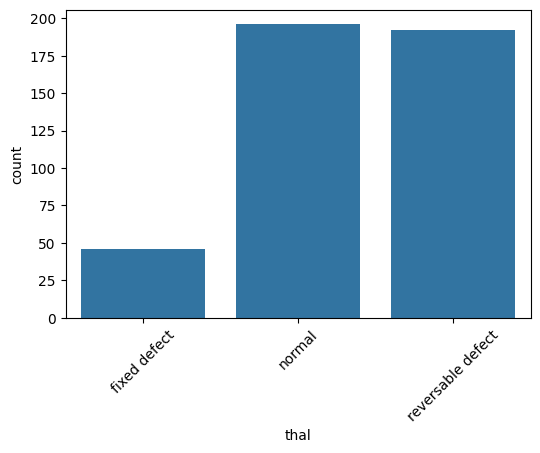

In [23]:
cat_cols = ['sex','cp','fbs','restecg','exang','slope','thal']
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

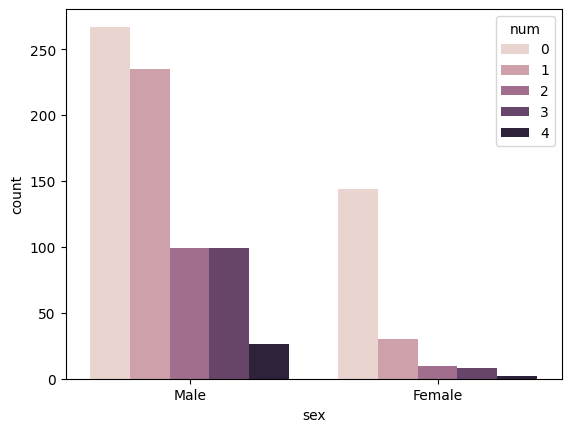

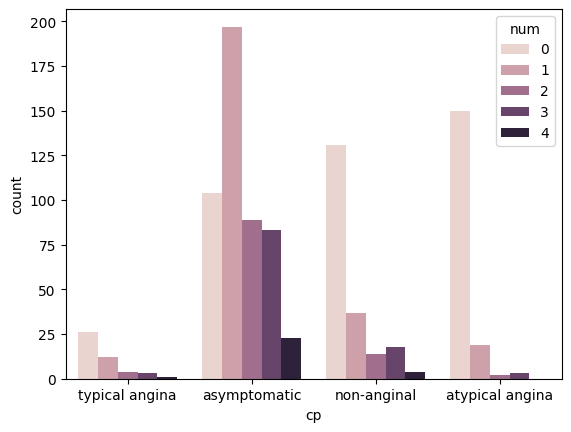

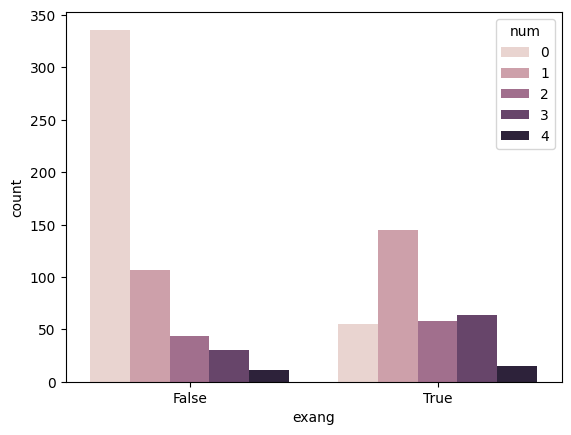

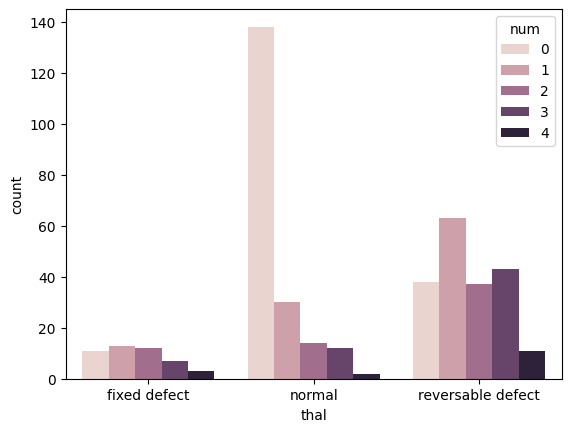

In [24]:
cat_cols_2 = ['sex','cp','exang','thal']
for i in cat_cols_2:
    sns.countplot(x=i,
                  hue='num',
                  data=df)
    plt.show()

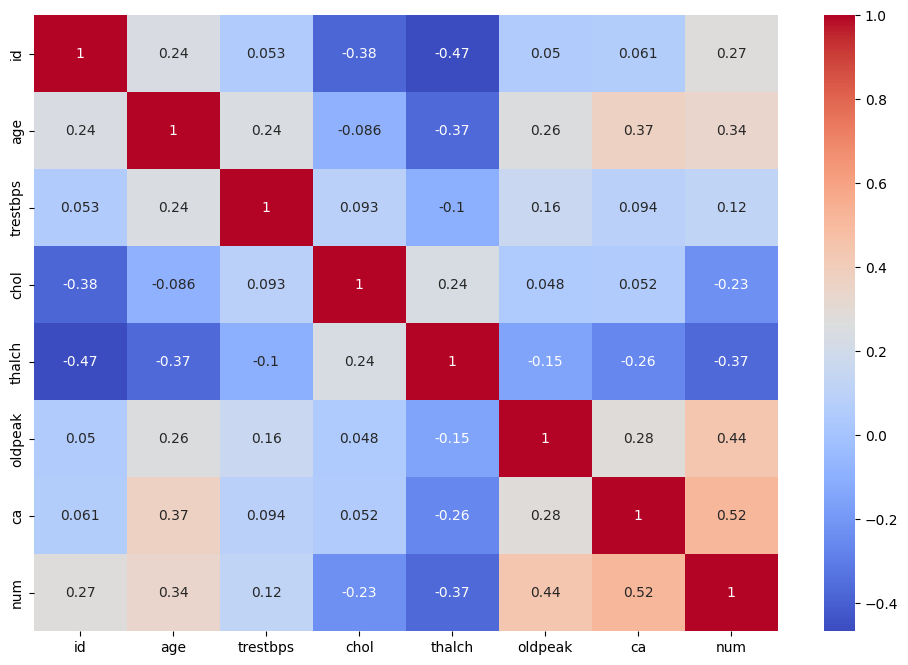

In [25]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')
plt.show()

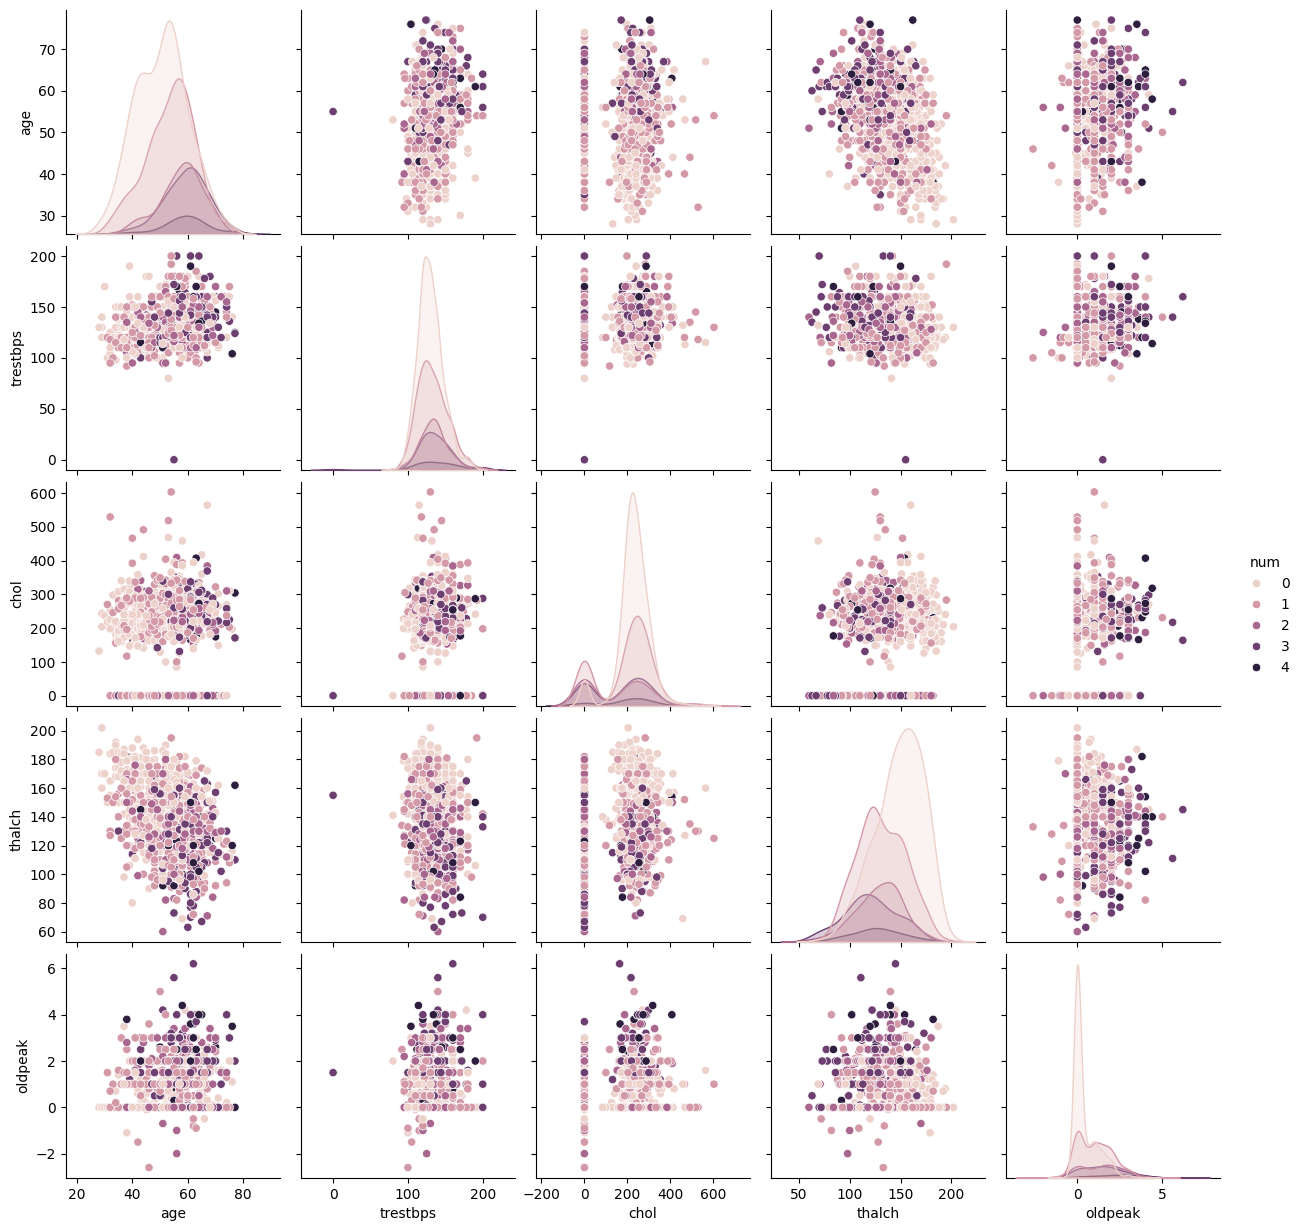

In [26]:
sns.pairplot(df[['age','trestbps','chol','thalch','oldpeak','num']],hue='num')
plt.show()

## PreProcessing

In [27]:
# Droping unnecessary columns
df.drop(['id','dataset','ca','thal'], axis=1, inplace=True)

# Numerical columns
for col in ['trestbps','chol','thalch','oldpeak']:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
for col in ['fbs','restecg','exang']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Slope
df['slope'].fillna(df['slope'].mode()[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_15084\2964715181.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_15084\2964715181.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

In [28]:
print(df.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'num']


## Feature Engineering

In [29]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore',dtype= np.int32)
encoded_data = ohe.fit_transform(df[['sex','cp','fbs','restecg','exang']])
encoded_df = pd.DataFrame(encoded_data,columns=ohe.get_feature_names_out(['sex','cp','fbs','restecg','exang']),index=df.index)

In [30]:
encoded_df.head()

,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True
0,1,0,0,1,1,0,0,0
1,1,0,0,0,0,0,0,1
2,1,0,0,0,0,0,0,1
3,1,0,1,0,0,1,0,0
4,0,1,0,0,0,0,0,0


In [31]:
df = df.drop(columns=['sex','cp','fbs','restecg','exang'])
df = pd.concat([df, encoded_df], axis=1)

In [32]:
df.head()

,age,trestbps,chol,thalch,oldpeak,slope,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True
0,63,145.0,233.0,150.0,2.3,downsloping,0,1,0,0,1,1,0,0,0
1,67,160.0,286.0,108.0,1.5,flat,2,1,0,0,0,0,0,0,1
2,67,120.0,229.0,129.0,2.6,flat,1,1,0,0,0,0,0,0,1
3,37,130.0,250.0,187.0,3.5,downsloping,0,1,0,1,0,0,1,0,0
4,41,130.0,204.0,172.0,1.4,upsloping,0,0,1,0,0,0,0,0,0


In [33]:
df['slope'].fillna(df['slope'].mode()[0], inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_15084\3864430711.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['slope'].fillna(df['slope'].mode()[0], inplace=True)


In [34]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=[["upsloping","flat","downsloping"]])
oe.fit(df[["slope"]])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['upsloping', 'flat', ...]]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide <encoder_infrequent_categories>`.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide <encoder_infrequent_categories>`.",None
Name,Type,Value
categories_ categories_: list of arraysThe categories of each feature determined during ``fit`` (in order ofthe features in X and corresponding with the output of ``transform``).This does not include categories that weren't seen during ``fit``.,list,[array(['upslo... dtype=object)]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['slope']
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 1.0,int,1


In [35]:
df["slope"] = oe.transform(df[["slope"]])

In [36]:
df.head()

,age,trestbps,chol,thalch,oldpeak,slope,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True
0,63,145.0,233.0,150.0,2.3,2.0,0,1,0,0,1,1,0,0,0
1,67,160.0,286.0,108.0,1.5,1.0,2,1,0,0,0,0,0,0,1
2,67,120.0,229.0,129.0,2.6,1.0,1,1,0,0,0,0,0,0,1
3,37,130.0,250.0,187.0,3.5,2.0,0,1,0,1,0,0,1,0,0
4,41,130.0,204.0,172.0,1.4,0.0,0,0,1,0,0,0,0,0,0


In [37]:
col = df.pop('num')
df['num'] = col

In [38]:
df.head()

,age,trestbps,chol,thalch,oldpeak,slope,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,num
0,63,145.0,233.0,150.0,2.3,2.0,1,0,0,1,1,0,0,0,0
1,67,160.0,286.0,108.0,1.5,1.0,1,0,0,0,0,0,0,1,2
2,67,120.0,229.0,129.0,2.6,1.0,1,0,0,0,0,0,0,1,1
3,37,130.0,250.0,187.0,3.5,2.0,1,0,1,0,0,1,0,0,0
4,41,130.0,204.0,172.0,1.4,0.0,0,1,0,0,0,0,0,0,0


## Train-test Splitting

In [39]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(df.iloc[:,:14],
                                                 df.iloc[:,-1],
                                                 test_size=0.2,
                                                 random_state=42)

In [40]:
X_train.head()

,age,trestbps,chol,thalch,oldpeak,slope,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True
880,62,130.0,170.0,120.0,3.0,1.0,1,0,0,0,0,0,1,1
457,54,150.0,223.0,122.0,0.0,1.0,1,0,1,0,0,1,0,0
797,51,130.0,339.0,140.0,0.5,1.0,1,0,1,0,0,1,0,0
25,50,120.0,219.0,158.0,1.6,1.0,0,0,1,0,0,1,0,0
84,52,120.0,325.0,172.0,0.2,0.0,1,1,0,0,0,1,0,0


In [41]:
X_train.shape

(736, 14)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [44]:
X_train_scaled.head()

,age,trestbps,chol,thalch,oldpeak,slope,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True
880,0.902413,-0.083946,-0.262575,-0.694187,1.983624,0.291800,0.505937,-0.482525,-0.533355,-0.230071,-0.401103,-1.212353,2.045262,1.321465
457,0.034776,0.987771,0.223659,-0.614999,-0.794406,0.291800,0.505937,-0.482525,1.874923,-0.230071,-0.401103,0.824843,-0.488935,-0.756736
797,-0.290587,-0.083946,1.287871,0.097694,-0.331401,0.291800,0.505937,-0.482525,1.874923,-0.230071,-0.401103,0.824843,-0.488935,-0.756736
25,-0.399042,-0.619805,0.186962,0.810387,0.687210,0.291800,-1.976529,-0.482525,1.874923,-0.230071,-0.401103,0.824843,-0.488935,-0.756736
84,-0.182133,-0.619805,1.159431,1.364703,-0.609204,-1.575721,0.505937,2.072429,-0.533355,-0.230071,-0.401103,0.824843,-0.488935,-0.756736


## Model_selection

In [45]:
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [65]:
import warnings
warnings.filterwarnings('ignore')

### SVC

In [46]:
from sklearn.svm import SVC                                                    
svc = SVC()
svc.fit(X_train_scaled, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [47]:
Y_pred1 = svc.predict(X_test_scaled)
confusion_matrix(Y_test, Y_pred1)

array([[70,  5,  0,  0,  0],
       [23, 28,  1,  2,  0],
       [ 6, 17,  1,  1,  0],
       [ 9, 15,  1,  1,  0],
       [ 0,  2,  1,  1,  0]])

In [49]:
accuracy_score(Y_test, Y_pred1)

0.5434782608695652

In [66]:
print(classification_report(Y_test, Y_pred1))

              precision    recall  f1-score   support

           0       0.65      0.93      0.77        75
           1       0.42      0.52      0.46        54
           2       0.25      0.04      0.07        25
           3       0.20      0.04      0.06        26
           4       0.00      0.00      0.00         4

    accuracy                           0.54       184
   macro avg       0.30      0.31      0.27       184
weighted avg       0.45      0.54      0.47       184



In [51]:
from sklearn.model_selection import GridSearchCV

# Parameter Grid
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100]
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1]
    }
]

# Grid Search
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,      # Using all CPU cores
    verbose=2       # progress
)

# Train Grid Search
grid.fit(X_train_scaled, Y_train)

# Best Parameters
print("Best Parameters:")
print(grid.best_params_)

# Best Cross-Validation Accuracy
print("\nBest CV Accuracy:")
print(grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

Best CV Accuracy:
0.5869369369369368


In [53]:
best_svc = grid.best_estimator_

Y_pred2 = best_svc.predict(X_test_scaled)
svm_accuracy = accuracy_score(Y_test, Y_pred2)

print("Test Accuracy:", accuracy_score(Y_test, Y_pred2))

Test Accuracy: 0.5380434782608695


### Decision_Tree

In [54]:
from sklearn.tree import DecisionTreeClassifier
clf=DecisionTreeClassifier()
clf.fit(X_train,Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [55]:
Y_pred3=clf.predict(X_test)

accuracy_score(Y_test,Y_pred3)

0.483695652173913

In [57]:
confusion_matrix(Y_test, Y_pred3)

array([[55, 13,  1,  6,  0],
       [18, 23, 10,  1,  2],
       [ 3,  8,  7,  6,  1],
       [ 7, 11,  4,  4,  0],
       [ 0,  0,  1,  3,  0]])

In [59]:
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

dt = DecisionTreeClassifier(random_state=42)


grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Train
grid.fit(X_train, Y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Accuracy:")
print(grid.best_score_)

Fitting 5 folds for each of 1008 candidates, totalling 5040 fits
Best Parameters:
{'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best CV Accuracy:
0.5761261261261261


In [62]:
best_dt = grid.best_estimator_

Y_pred4 = best_dt.predict(X_test)
dt_accuracy = accuracy_score(Y_test, Y_pred4)

print("Test Accuracy:", dt_accuracy)

Test Accuracy: 0.5217391304347826


### Voting_Classifier

In [67]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score


lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()

voting = VotingClassifier(estimators=[('lr', lr),('svm', svm),('knn', knn),('dt', dt)],voting='soft')

x = cross_val_score(voting,
                    X_train_scaled,
                    Y_train,
                    cv=10,
                    scoring='accuracy')


voting.fit(X_train_scaled, Y_train)
Y_pred5 = voting.predict(X_test_scaled)

In [68]:
vc_accuracy = accuracy_score(Y_test, Y_pred5)
print("Accuracy:",vc_accuracy )

Accuracy: 0.5543478260869565


### Gradient Boosting

In [69]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier()

gbc.fit(X_train, Y_train)
Y_pred6 = gbc.predict(X_test)
print(classification_report(Y_test, Y_pred6))

              precision    recall  f1-score   support

           0       0.69      0.91      0.79        75
           1       0.43      0.48      0.46        54
           2       0.33      0.20      0.25        25
           3       0.22      0.08      0.11        26
           4       0.00      0.00      0.00         4

    accuracy                           0.55       184
   macro avg       0.34      0.33      0.32       184
weighted avg       0.49      0.55      0.50       184



In [71]:
accuracy_score(Y_test,Y_pred6)

0.5489130434782609

In [73]:
confusion_matrix(Y_test, Y_pred6)

array([[68,  5,  1,  1,  0],
       [20, 26,  5,  2,  1],
       [ 4, 13,  5,  2,  1],
       [ 6, 15,  3,  2,  0],
       [ 0,  1,  1,  2,  0]])

In [74]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}

random_search_gb = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search_gb.fit(X_train, Y_train)

print("Best Parameters:")
print(random_search_gb.best_params_)

print("\nBest CV Accuracy:")
print(random_search_gb.best_score_)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.01}

Best CV Accuracy:
0.5720314141916929


In [76]:
best_gbm = grid.best_estimator_

Y_pred7 = best_gbm.predict(X_test)
gbm_accuracy = accuracy_score(Y_test, Y_pred7)

print("Test Accuracy:", gbm_accuracy)

Test Accuracy: 0.5217391304347826


In [77]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_gb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
13,exang_True,0.190429
2,chol,0.144367
4,oldpeak,0.123927
0,age,0.121222
3,thalch,0.101045
7,cp_atypical angina,0.096368
1,trestbps,0.060897
6,sex_Male,0.060180
8,cp_non-anginal,0.057360
11,restecg_normal,0.012811


### XG_Boost

In [80]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [82]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, Y_train)
Y_pred8 = xgb.predict(X_test)

print(classification_report(Y_test, Y_pred8))

              precision    recall  f1-score   support

           0       0.70      0.88      0.78        75
           1       0.47      0.50      0.49        54
           2       0.39      0.28      0.33        25
           3       0.31      0.15      0.21        26
           4       0.00      0.00      0.00         4

    accuracy                           0.57       184
   macro avg       0.37      0.36      0.36       184
weighted avg       0.52      0.57      0.53       184



In [84]:
print("Accuracy:", accuracy_score(Y_test, Y_pred8))

Accuracy: 0.5652173913043478


In [86]:
confusion_matrix(Y_test, Y_pred8)

array([[66,  6,  2,  1,  0],
       [17, 27,  7,  3,  0],
       [ 3, 11,  7,  3,  1],
       [ 8, 11,  2,  4,  1],
       [ 0,  2,  0,  2,  0]])

In [88]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5]
}

random_search_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=param_dist,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# Train Grid Search
random_search_xgb.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 0.9, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",

In [89]:
print("Best Parameters:")
print(random_search_gb.best_params_)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.01}


In [90]:
print("\nBest CV Accuracy:")
print(random_search_gb.best_score_)


Best CV Accuracy:
0.5720314141916929


In [91]:
best_xgb = random_search_xgb.best_estimator_

Y_pred9 = best_xgb.predict(X_test)
xgb_accuracy = accuracy_score(Y_test, Y_pred9)

print("Test Accuracy:", xgb_accuracy)

Test Accuracy: 0.5706521739130435


## Compairing

In [92]:
comparison = pd.DataFrame({
    'Model': [
        'SVM',
        'Decision Trees',
        'Gradient Boosting',
        'Voting Classifier',
        'XG Boosting'
    ],
    'Accuracy': [
        svm_accuracy,
        dt_accuracy,
        gbm_accuracy,
        vc_accuracy,
        xgb_accuracy
    ]
})

comparison = comparison.sort_values(
    by='Accuracy',
    ascending=False
)

comparison

,Model,Accuracy
4,XG Boosting,0.570652
3,Voting Classifier,0.554348
0,SVM,0.538043
1,Decision Trees,0.521739
2,Gradient Boosting,0.521739


## Importing